# Deteção de Texto IA vs Humano — Transformer (do zero)

Implementação de um Transformer de classificação construído em PyTorch puro,  
adaptado do `transformer-imdb.py` para classificação multi-classe com **early stopping**.

**Classes:** `Human · Google · Meta · OpenAI · Anthropic`

**Arquitetura:**
```
Texto → Integer Encoding → Embedding + Positional Embedding
      → MultiheadAttention → LayerNorm → FeedForward → LayerNorm
      → Mean Pooling → Linear(5) → CrossEntropyLoss
```

## 1. Imports

In [10]:
import re
import math
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Imports OK")

Imports OK


## 2. Configuração

In [11]:
TRAIN_PATH  = "data/train.csv"
TEST_PATH   = "data/test.csv"
TEXT_COL    = "Text"
LABEL_COL   = "Label"

LABELS      = ["Human", "Google", "Meta", "OpenAI", "Anthropic"]
LABEL2IDX   = {l: i for i, l in enumerate(LABELS)}
IDX2LABEL   = {i: l for l, i in LABEL2IDX.items()}
NUM_CLASSES = len(LABELS)

# ── Representação de texto ────────────────────────────────────────────────────
MAX_WORDS   = 20000   # tamanho do vocabulário
MAX_LEN     = 150     # tokens por texto (textos de 80-120 palavras → 150 com margem)

# ── Arquitectura do Transformer ───────────────────────────────────────────────
EMBED_DIM   = 128     # dimensão dos embeddings
NUM_HEADS   = 4       # cabeças de atenção (EMBED_DIM deve ser divisível por NUM_HEADS)
FF_DIM      = 256     # dimensão interna do feed-forward
NUM_LAYERS  = 2       # blocos Transformer empilhados
DROPOUT     = 0.3

# ── Treino ────────────────────────────────────────────────────────────────────
BATCH_SIZE  = 64
LR          = 0.001
MAX_EPOCHS  = 50      # máximo de épocas — early stopping vai parar antes
VAL_SPLIT   = 0.2
SEED        = 42

# ── Early Stopping ────────────────────────────────────────────────────────────
ES_PATIENCE = 5       # épocas sem melhoria antes de parar
ES_MIN_DELTA= 1e-4    # melhoria mínima considerada relevante
ES_MONITOR  = "val_loss"   # métrica a monitorizar: "val_loss" ou "val_acc"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else
                      "mps"  if torch.backends.mps.is_available() else "cpu")
print(f"Device : {DEVICE}")
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Device : cpu


## 3. Pré-processamento e Vocabulário

In [12]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def build_vocab(texts, max_words=10000):
    counter = Counter()
    for text in texts:
        counter.update(text.split())
    most_common = counter.most_common(max_words)
    # índice 0 reservado para PAD, 1 para palavras desconhecidas (UNK)
    return {word: i + 2 for i, (word, _) in enumerate(most_common)}

def encode(text, word_index, max_len):
    tokens = text.split()   # texto já limpo
    seq = [word_index.get(w, 1) for w in tokens][:max_len]   # 1 = UNK
    seq += [0] * (max_len - len(seq))                         # 0 = PAD
    return torch.tensor(seq, dtype=torch.long)

## 4. Dataset e DataLoaders

In [13]:
class AuthorDataset(Dataset):
    def __init__(self, texts, labels, word_index, max_len):
        self.texts      = texts
        self.labels     = labels
        self.word_index = word_index
        self.max_len    = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        return (encode(self.texts[idx], self.word_index, self.max_len),
                torch.tensor(self.labels[idx], dtype=torch.long))

In [14]:
def load_csv(path):
    df = pd.read_csv(path, sep=";")
    texts  = [clean_text(t) for t in df[TEXT_COL].tolist()]
    labels = [LABEL2IDX[l] for l in df[LABEL_COL].tolist()]
    return texts, labels

all_train_texts, all_train_labels = load_csv(TRAIN_PATH)
test_texts,      test_labels      = load_csv(TEST_PATH)

train_texts, val_texts, train_labels, val_labels = train_test_split(
    all_train_texts, all_train_labels,
    test_size=VAL_SPLIT, random_state=SEED, stratify=all_train_labels
)

# Vocabulário só nos dados de treino (evita leakage)
word_index = build_vocab(train_texts, MAX_WORDS)
VOCAB_SIZE = len(word_index) + 2   # +2 por PAD e UNK

train_loader = DataLoader(AuthorDataset(train_texts, train_labels, word_index, MAX_LEN),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(AuthorDataset(val_texts,   val_labels,   word_index, MAX_LEN),
                          batch_size=BATCH_SIZE)
test_loader  = DataLoader(AuthorDataset(test_texts,  test_labels,  word_index, MAX_LEN),
                          batch_size=BATCH_SIZE)

print(f"Treino    : {len(train_texts)}")
print(f"Validação : {len(val_texts)}")
print(f"Teste     : {len(test_texts)}")
print(f"Vocab     : {VOCAB_SIZE}")

Treino    : 21200
Validação : 5300
Teste     : 314
Vocab     : 20002


## 5. Modelo — TransformerClassifier

Usa `nn.MultiheadAttention` nativo do PyTorch (mais eficiente que implementação manual),  
com positional embedding **aprendido** (em vez de senos/cossenos fixos) e suporte a múltiplos blocos empilhados.

In [15]:
class TransformerBlock(nn.Module):
    """Um bloco Transformer: Attention → Add&Norm → FFN → Add&Norm."""
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.attention = nn.MultiheadAttention(embed_dim, num_heads,
                                               dropout=dropout, batch_first=True)
        self.norm1   = nn.LayerNorm(embed_dim)
        self.norm2   = nn.LayerNorm(embed_dim)
        self.ff      = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, embed_dim),
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, key_padding_mask=None):
        # Self-attention + residual
        attn_out, _ = self.attention(x, x, x, key_padding_mask=key_padding_mask)
        x = self.norm1(x + self.dropout(attn_out))
        # Feed-forward + residual
        x = self.norm2(x + self.ff(x))
        return x


class TransformerClassifier(nn.Module):
    """
    Transformer para classificação multi-classe.
    Empilha `num_layers` blocos Transformer e usa mean pooling para classificar.
    Passa a padding mask à atenção para ignorar tokens PAD no cálculo dos pesos.
    """
    def __init__(self, vocab_size, embed_dim, num_heads, ff_dim,
                 max_len, num_layers=2, dropout=0.1, num_classes=NUM_CLASSES):
        super().__init__()
        self.embedding     = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_embedding = nn.Embedding(max_len, embed_dim)
        self.dropout       = nn.Dropout(dropout)
        self.blocks        = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):   # x: (B, max_len)
        B, L = x.shape

        # Padding mask: True onde o token é PAD (ignorado pela atenção)
        pad_mask = (x == 0)   # (B, L)

        # Embeddings + positional
        positions = torch.arange(L, device=x.device).unsqueeze(0).expand(B, L)
        out = self.dropout(self.embedding(x) + self.pos_embedding(positions))

        # Blocos Transformer
        for block in self.blocks:
            out = block(out, key_padding_mask=pad_mask)

        # Mean pooling apenas sobre tokens não-PAD
        mask_float = (~pad_mask).unsqueeze(-1).float()   # (B, L, 1)
        pooled = (out * mask_float).sum(dim=1) / mask_float.sum(dim=1).clamp(min=1)

        return self.classifier(pooled)   # (B, num_classes)


model = TransformerClassifier(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    ff_dim=FF_DIM,
    max_len=MAX_LEN,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nParâmetros treináveis: {n_params:,}")

TransformerClassifier(
  (embedding): Embedding(20002, 128, padding_idx=0)
  (pos_embedding): Embedding(150, 128)
  (dropout): Dropout(p=0.3, inplace=False)
  (blocks): ModuleList(
    (0-1): 2 x TransformerBlock(
      (attention): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
      )
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (ff): Sequential(
        (0): Linear(in_features=128, out_features=256, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.3, inplace=False)
        (3): Linear(in_features=256, out_features=128, bias=True)
      )
      (dropout): Dropout(p=0.3, inplace=False)
    )
  )
  (classifier): Linear(in_features=128, out_features=5, bias=True)
)

Parâmetros treináveis: 2,845,061


## 6. Early Stopping

In [16]:
class EarlyStopping:
    """
    Para o treino quando a métrica monitorizada não melhora.
    Guarda o melhor modelo em memória para restaurar no final.

    monitor   : "val_loss" (minimizar) ou "val_acc" (maximizar)
    patience  : épocas toleradas sem melhoria
    min_delta : melhoria mínima para contar como progresso
    """
    def __init__(self, patience=5, min_delta=1e-4, monitor="val_loss"):
        self.patience   = patience
        self.min_delta  = min_delta
        self.monitor    = monitor
        self.maximize   = (monitor == "val_acc")
        self.best       = -np.inf if self.maximize else np.inf
        self.counter    = 0
        self.best_state = None
        self.stopped_epoch = 0

    def step(self, value, model, epoch):
        """Devolve True se o treino deve parar."""
        improved = (value > self.best + self.min_delta) if self.maximize \
                   else (value < self.best - self.min_delta)

        if improved:
            self.best       = value
            self.counter    = 0
            # Guardar cópia dos pesos do melhor modelo
            self.best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1

        if self.counter >= self.patience:
            self.stopped_epoch = epoch
            return True
        return False

    def restore(self, model):
        """Restaura os pesos do melhor modelo."""
        if self.best_state:
            model.load_state_dict(self.best_state)
            print(f"  → Pesos restaurados para a época com melhor {self.monitor}: {self.best:.4f}")

print("EarlyStopping OK")

EarlyStopping OK


## 7. Treino e Avaliação

In [17]:
criterion = nn.CrossEntropyLoss()

def evaluate_loader(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out  = model(x)
            total_loss += criterion(out, y).item()
            correct    += (out.argmax(1) == y).sum().item()
            total      += y.size(0)
    return total_loss / len(loader), correct / total


def train_model(model, train_loader, val_loader,
                max_epochs=MAX_EPOCHS, lr=LR,
                patience=ES_PATIENCE, min_delta=ES_MIN_DELTA, monitor=ES_MONITOR):

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # Scheduler: reduz LR se val_loss estagnar (complementa early stopping)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3
    )
    early_stop = EarlyStopping(patience=patience, min_delta=min_delta, monitor=monitor)
    history    = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    print(f"Treino com early stopping (patience={patience}, monitor={monitor})")
    print("=" * 60)

    for epoch in range(1, max_epochs + 1):
        model.train()
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            criterion(model(x), y).backward()
            # Gradient clipping — importante em Transformers
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        tr_loss, tr_acc = evaluate_loader(model, train_loader)
        vl_loss, vl_acc = evaluate_loader(model, val_loader)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)

        scheduler.step(vl_loss)

        print(f"Época {epoch:03d}/{max_epochs} | "
              f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | "
              f"Val Loss {vl_loss:.4f} Acc {vl_acc:.4f}"
              + (f" ✓" if early_stop.counter == 0 else f" [{early_stop.counter}/{patience}]"))

        monitor_val = vl_loss if monitor == "val_loss" else vl_acc
        if early_stop.step(monitor_val, model, epoch):
            print(f"\nEarly stopping na época {epoch} (sem melhoria há {patience} épocas).")
            break

    early_stop.restore(model)
    print(f"\nTreino concluído. Melhor época: {epoch - patience}")
    return history

In [18]:
history = train_model(model, train_loader, val_loader)

Treino com early stopping (patience=5, monitor=val_loss)
Época 001/50 | Train Loss 0.7408 Acc 0.6954 | Val Loss 0.7766 Acc 0.6834 ✓
Época 002/50 | Train Loss 0.5759 Acc 0.7838 | Val Loss 0.6390 Acc 0.7609 ✓
Época 003/50 | Train Loss 0.4886 Acc 0.8173 | Val Loss 0.5824 Acc 0.7815 ✓
Época 004/50 | Train Loss 0.4541 Acc 0.8331 | Val Loss 0.5802 Acc 0.7840 ✓
Época 005/50 | Train Loss 0.3818 Acc 0.8530 | Val Loss 0.5277 Acc 0.8002 ✓
Época 006/50 | Train Loss 0.3232 Acc 0.8771 | Val Loss 0.5120 Acc 0.8070 ✓
Época 007/50 | Train Loss 0.3115 Acc 0.8821 | Val Loss 0.5146 Acc 0.8158 ✓
Época 008/50 | Train Loss 0.2782 Acc 0.8974 | Val Loss 0.5155 Acc 0.8206 [1/5]
Época 009/50 | Train Loss 0.2705 Acc 0.9007 | Val Loss 0.5177 Acc 0.8219 [2/5]
Época 010/50 | Train Loss 0.2306 Acc 0.9160 | Val Loss 0.5039 Acc 0.8192 [3/5]
Época 011/50 | Train Loss 0.1977 Acc 0.9290 | Val Loss 0.4999 Acc 0.8264 ✓
Época 012/50 | Train Loss 0.1934 Acc 0.9308 | Val Loss 0.5108 Acc 0.8283 ✓
Época 013/50 | Train Loss 0.168

## 8. Curvas de Aprendizagem

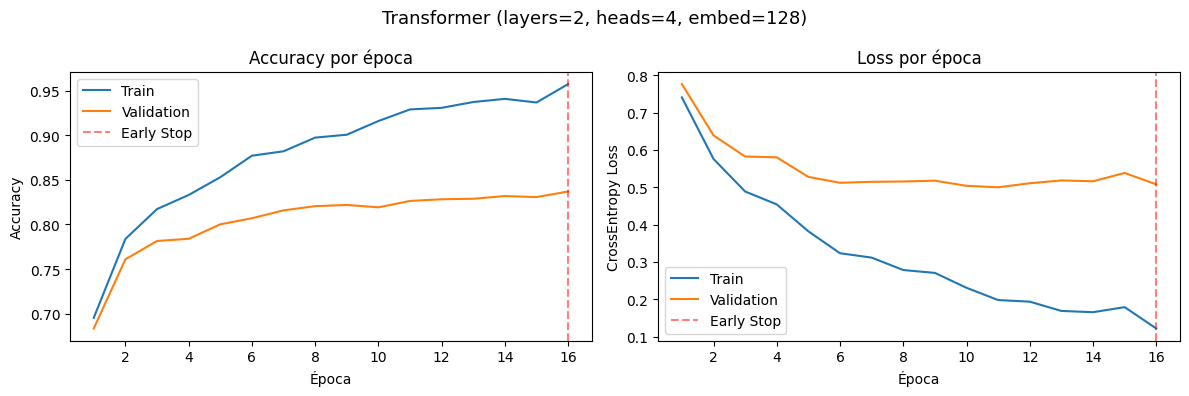

In [19]:
def plot_history(history, title="Transformer"):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history["train_acc"],  label="Train")
    axes[0].plot(epochs, history["val_acc"],    label="Validation")
    axes[0].set_title("Accuracy por época")
    axes[0].set_xlabel("Época"); axes[0].set_ylabel("Accuracy")
    axes[0].legend()

    axes[1].plot(epochs, history["train_loss"], label="Train")
    axes[1].plot(epochs, history["val_loss"],   label="Validation")
    axes[1].set_title("Loss por época")
    axes[1].set_xlabel("Época"); axes[1].set_ylabel("CrossEntropy Loss")
    axes[1].legend()

    # Linha vertical onde parou (se houve early stopping)
    n_epochs = len(history["train_loss"])
    if n_epochs < MAX_EPOCHS:
        for ax in axes:
            ax.axvline(x=n_epochs, color="red", linestyle="--", alpha=0.5, label="Early Stop")
        axes[0].legend(); axes[1].legend()

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

plot_history(history, title=f"Transformer (layers={NUM_LAYERS}, heads={NUM_HEADS}, embed={EMBED_DIM})")

## 9. Avaliação no Conjunto de Teste

In [20]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        preds = model(x.to(DEVICE)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())

_, test_acc = evaluate_loader(model, test_loader)
print(f"\nTest Accuracy: {test_acc:.4f}\n")
print(classification_report(all_labels, all_preds, target_names=LABELS, zero_division=0))


Test Accuracy: 0.4268

              precision    recall  f1-score   support

       Human       0.60      0.89      0.71       116
      Google       0.33      0.02      0.04        51
        Meta       1.00      0.02      0.04        51
      OpenAI       0.21      0.66      0.32        44
   Anthropic       0.00      0.00      0.00        52

    accuracy                           0.43       314
   macro avg       0.43      0.32      0.22       314
weighted avg       0.47      0.43      0.32       314



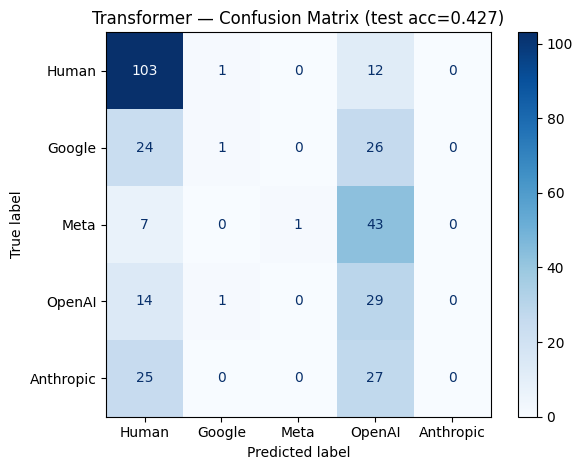

In [21]:
cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=LABELS).plot(cmap="Blues")
plt.title(f"Transformer — Confusion Matrix (test acc={test_acc:.3f})")
plt.tight_layout()
plt.show()

Exemplos carregados: 100
Label
Human        34
Google       18
OpenAI       16
Anthropic    16
Meta         16
Name: count, dtype: int64

Accuracy em data/subm2_test.csv: 0.4000

              precision    recall  f1-score   support

       Human       0.60      0.79      0.68        34
      Google       0.00      0.00      0.00        18
        Meta       0.00      0.00      0.00        16
      OpenAI       0.24      0.81      0.37        16
   Anthropic       0.00      0.00      0.00        16

    accuracy                           0.40       100
   macro avg       0.17      0.32      0.21       100
weighted avg       0.24      0.40      0.29       100



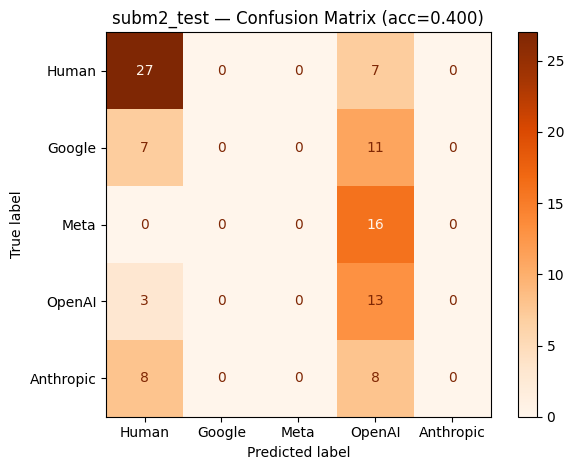

In [22]:
# ── Teste extra: subm2_test.csv ───────────────────────────────────────────────
EXTRA_TEST_PATH = "data/subm2_test.csv"

df_extra = pd.read_csv(EXTRA_TEST_PATH, sep=";")
print(f"Exemplos carregados: {len(df_extra)}")
print(df_extra[LABEL_COL].value_counts())

# Pré-processar com o mesmo vocab do treino
extra_texts  = [clean_text(t) for t in df_extra[TEXT_COL].tolist()]
extra_labels = [LABEL2IDX[l] for l in df_extra[LABEL_COL].tolist()]

extra_loader = DataLoader(
    AuthorDataset(extra_texts, extra_labels, word_index, MAX_LEN),
    batch_size=BATCH_SIZE
)

# Inferência
model.eval()
extra_preds, extra_true = [], []
with torch.no_grad():
    for x, y in extra_loader:
        preds = model(x.to(DEVICE)).argmax(1).cpu().numpy()
        extra_preds.extend(preds)
        extra_true.extend(y.numpy())

_, extra_acc = evaluate_loader(model, extra_loader)
print(f"\nAccuracy em {EXTRA_TEST_PATH}: {extra_acc:.4f}\n")
print(classification_report(extra_true, extra_preds, target_names=LABELS, zero_division=0))

cm_extra = confusion_matrix(extra_true, extra_preds)
ConfusionMatrixDisplay(cm_extra, display_labels=LABELS).plot(cmap="Oranges")
plt.title(f"subm2_test — Confusion Matrix (acc={extra_acc:.3f})")
plt.tight_layout()
plt.show()

## 10. Experiências — variações rápidas

Recria o modelo com configurações diferentes e corre novamente.  
O early stopping vai parar automaticamente quando a val_loss estagnar.

Treino com early stopping (patience=5, monitor=val_loss)
Época 001/50 | Train Loss 0.7764 Acc 0.6991 | Val Loss 0.8042 Acc 0.6868 ✓
Época 002/50 | Train Loss 0.6083 Acc 0.7625 | Val Loss 0.6573 Acc 0.7470 ✓
Época 003/50 | Train Loss 0.5258 Acc 0.7991 | Val Loss 0.6055 Acc 0.7655 ✓
Época 004/50 | Train Loss 0.4721 Acc 0.8223 | Val Loss 0.5743 Acc 0.7845 ✓
Época 005/50 | Train Loss 0.4227 Acc 0.8383 | Val Loss 0.5562 Acc 0.7862 ✓
Época 006/50 | Train Loss 0.3637 Acc 0.8636 | Val Loss 0.5262 Acc 0.8008 ✓
Época 007/50 | Train Loss 0.3429 Acc 0.8704 | Val Loss 0.5361 Acc 0.8030 ✓
Época 008/50 | Train Loss 0.2974 Acc 0.8927 | Val Loss 0.5202 Acc 0.8181 [1/5]
Época 009/50 | Train Loss 0.2831 Acc 0.8945 | Val Loss 0.5276 Acc 0.8128 ✓
Época 010/50 | Train Loss 0.2470 Acc 0.9087 | Val Loss 0.5080 Acc 0.8213 [1/5]
Época 011/50 | Train Loss 0.2231 Acc 0.9202 | Val Loss 0.5112 Acc 0.8226 ✓
Época 012/50 | Train Loss 0.1919 Acc 0.9336 | Val Loss 0.5105 Acc 0.8285 [1/5]
Época 013/50 | Train Loss 0.182

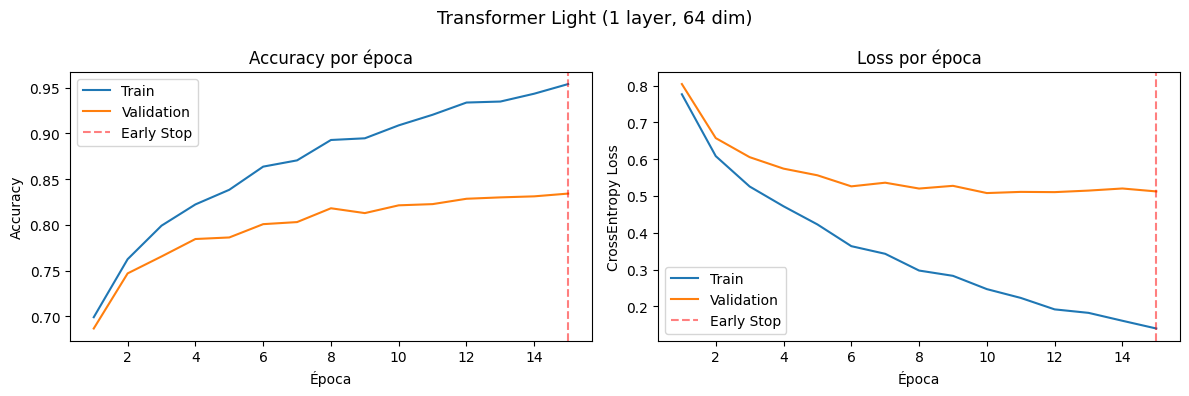


Transformer Light (1 layer, 64 dim) — Test Accuracy: 0.4172
              precision    recall  f1-score   support

       Human       0.60      0.86      0.70       116
      Google       0.00      0.00      0.00        51
        Meta       0.00      0.00      0.00        51
      OpenAI       0.22      0.70      0.33        44
   Anthropic       0.00      0.00      0.00        52

    accuracy                           0.42       314
   macro avg       0.16      0.31      0.21       314
weighted avg       0.25      0.42      0.31       314



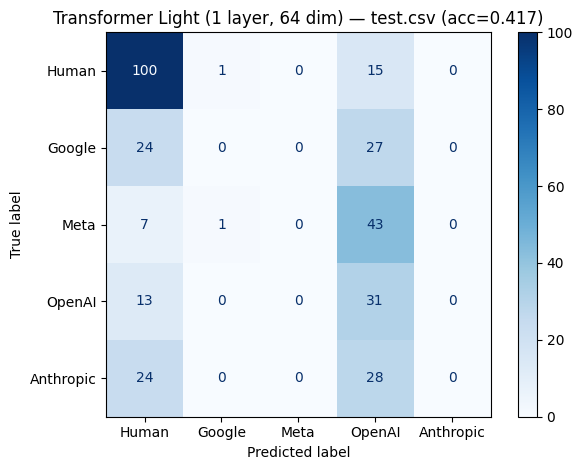


Transformer Light (1 layer, 64 dim) — subm2 Accuracy: 0.4200
              precision    recall  f1-score   support

       Human       0.57      0.82      0.67        34
      Google       0.00      0.00      0.00        18
        Meta       0.00      0.00      0.00        16
      OpenAI       0.27      0.88      0.42        16
   Anthropic       0.00      0.00      0.00        16

    accuracy                           0.42       100
   macro avg       0.17      0.34      0.22       100
weighted avg       0.24      0.42      0.30       100



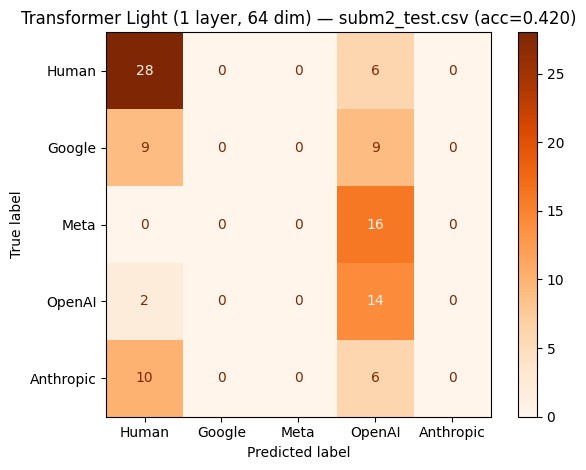

In [ ]:
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    
# ── Função reutilizável de avaliação completa ─────────────────────────────────
def run_experiment(model, title):
    """Treina, plota curvas e avalia em test + subm2."""
    torch.manual_seed(SEED)

    history = train_model(model, train_loader, val_loader)
    plot_history(history, title=title)

    # ── test.csv ──
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for x, y in test_loader:
            preds.extend(model(x.to(DEVICE)).argmax(1).cpu().numpy())
            trues.extend(y.numpy())
    _, test_acc = evaluate_loader(model, test_loader)
    print(f"\n{title} — Test Accuracy: {test_acc:.4f}")
    print(classification_report(trues, preds, target_names=LABELS, zero_division=0))
    ConfusionMatrixDisplay(confusion_matrix(trues, preds), display_labels=LABELS).plot(cmap="Blues")
    plt.title(f"{title} — test.csv (acc={test_acc:.3f})")
    plt.tight_layout(); plt.show()

    # ── subm2_test.csv ──
    df_subm2 = pd.read_csv("data/subm2_test.csv", sep=";")
    subm2_texts  = [clean_text(t) for t in df_subm2[TEXT_COL].tolist()]
    subm2_labels = [LABEL2IDX[l] for l in df_subm2[LABEL_COL].tolist()]
    subm2_loader = DataLoader(
        AuthorDataset(subm2_texts, subm2_labels, word_index, MAX_LEN),
        batch_size=64
    )
    preds2, trues2 = [], []
    with torch.no_grad():
        for x, y in subm2_loader:
            preds2.extend(model(x.to(DEVICE)).argmax(1).cpu().numpy())
            trues2.extend(y.numpy())
    _, subm2_acc = evaluate_loader(model, subm2_loader)
    print(f"\n{title} — subm2 Accuracy: {subm2_acc:.4f}")
    print(classification_report(trues2, preds2, target_names=LABELS, zero_division=0))
    ConfusionMatrixDisplay(confusion_matrix(trues2, preds2), display_labels=LABELS).plot(cmap="Oranges")
    plt.title(f"{title} — subm2_test.csv (acc={subm2_acc:.3f})")
    plt.tight_layout(); plt.show()


# VARIAÇÕES

# Modelo default (já treinado acima — reavaliar sem re-treinar)
# run_experiment(model, "Transformer Base (2 layers, 128 dim)")

# Mais profundo
#run_experiment(
#    TransformerClassifier(vocab_size=VOCAB_SIZE, embed_dim=256, num_heads=8,
#                          ff_dim=512, max_len=MAX_LEN, num_layers=4, dropout=0.4).to(DEVICE),
#    "Transformer Deep (4 layers, 256 dim)"
#)

# Mais leve
run_experiment(
    TransformerClassifier(vocab_size=VOCAB_SIZE, embed_dim=64, num_heads=4,
                          ff_dim=128, max_len=MAX_LEN, num_layers=1, dropout=0.2).to(DEVICE),
    "Transformer Light (1 layer, 64 dim)"
)

default -> 0.43 test, 0.40 subm2

profundo -> 0.42 test, ? subm2

leve -> 0.417 test, 0.42 subm2